In [1]:
from pathlib import Path
import sys

import pandas as pd
root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from weather_stylist.ml.synthetic_dataset import generate_synthetic_dataset
from weather_stylist.ml.train_model import main as train_warmth_model
from weather_stylist.ml.features import FEATURE_COLUMNS
from weather_stylist.ml.model_loader import get_regressor


ml_dir = root / "weather_stylist" / "ml"
data_dir = ml_dir / "data"
csv_path = data_dir / "synthetic_feedback.csv"
csv_path

PosixPath('/mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv')

## Модель комфортного индекса теплоты 

### Синтетический датасет

Сгенерируем синтетический датасет. В synthetic_dataset.generate_synthetic_dataset по умолчанию 5000 примеров


In [2]:
generate_synthetic_dataset(n_samples=5000)

synthetic dataset saved to /mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/data/synthetic_feedback.csv


Пример синтетических данных

In [3]:
df = pd.read_csv(csv_path)  # первые 5 строк
df.head()


,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
0,-17,-8,2.917356,0,1,0.0,10.0
1,-4,2,3.616451,1,0,0.0,8.0
2,23,29,10.148539,1,0,0.0,4.0
3,5,10,7.645419,0,-1,0.0,7.0
4,-2,7,1.719579,1,0,0.0,7.0


Средняя информация по всем объектам:

In [4]:
df.describe(include="all")

,temp_min,temp_max,wind_max,will_rain,thermo_profile,warmth_shift,required_warmth
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.0,5000.00000
mean,2.242600,7.226400,7.606232,0.498200,-0.00940,0.0,7.42400
std,16.417041,16.156985,4.364522,0.500047,0.81403,0.0,4.42856
min,-30.000000,-20.000000,0.006020,0.000000,-1.00000,0.0,1.00000
25%,-12.000000,-7.000000,3.781510,0.000000,-1.00000,0.0,4.00000
50%,2.000000,7.000000,7.644075,0.000000,0.00000,0.0,7.00000
75%,16.000000,21.000000,11.418951,1.000000,1.00000,0.0,11.00000
max,35.000000,35.000000,14.999875,1.000000,1.00000,0.0,18.00000


### Обучение модели

Запускаем обучвение модели. Вызываем train_madel.py, который читает датасет, там происходит деление на train/val, считаются метрики, модель сохраняется

In [5]:
train_warmth_model()

MAE: 0.37384729592999066
R^2: 0.9896416323946738
model saved to /mnt/d/hw/python_adv/final-project-adv-python/weather_stylist/ml/comfort_regressor.pkl


В качестве модели используется RandomForestRegressor из библиотеки scikit-learn с 200 деревьями (n_estimators=200) и ограничением глубины деревьев (max_depth=8), что позволяет моделировать нелинейную зависимость между погодой, профилем пользователя и требуемой «теплотой» комплекта, но при этом ограничивать переобучение.

In [6]:
reg = get_regressor()
reg

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [7]:
sample = df.iloc[0]

X_sample = sample[FEATURE_COLUMNS].values.reshape(1, -1)
y_true = sample["required_warmth"]
y_pred = reg.predict(X_sample)[0]

print("y_true:", y_true)
print("y_pred:", y_pred)


y_true: 10.0
y_pred: 10.2211299175845


/mnt/d/hw/python_adv/final-project-adv-python/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


MAE on test: 0.374
R^2 on test: 0.990


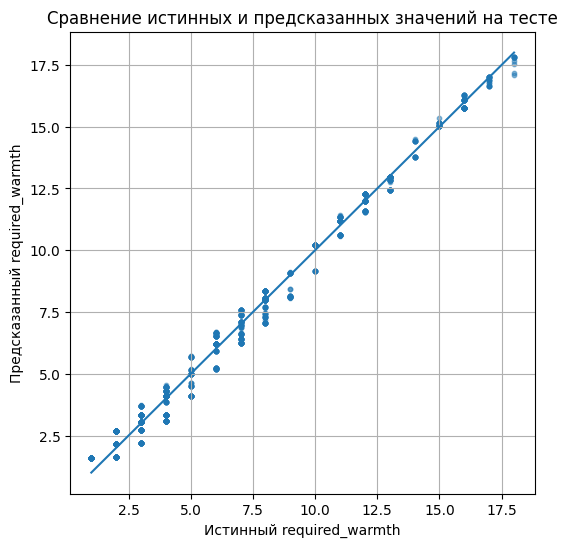

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

X = df[FEATURE_COLUMNS]
y = df["required_warmth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MAE on test: {mae:.3f}")
print(f"R^2 on test: {r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Истинный required_warmth")
plt.ylabel("Предсказанный required_warmth")
plt.title("Сравнение истинных и предсказанных значений на тесте")
plt.grid(True)
plt.show()


### Покажем на примере свзяь с ботом

Соберём искусственный прогноз погоды на день

In [9]:
from weather_stylist.models.weather import DayForecast
from weather_stylist.models.user import User
from weather_stylist.ml.features import make_features

# пример прогноза на день
fake_forecast = DayForecast(
    city="Prague",
    min_temp=3.0,
    max_temp=9.0,
    wind_max=5.0,
    will_rain=True, 
)

# пример пользователя
fake_user = User(
    tg_id=123456,
    city="Prague",
    name="Test User",
    region="unknown",
    thermo_profile=0,  
    warmth_shift=0.0,
    feedback_count=0,
    cold_count=0,
    hot_count=0,
)

features_vec = make_features(fake_forecast, fake_user)
features_vec


[3.0, 9.0, 5.0, 1.0, 0.0, 0.0]

In [10]:
X = pd.DataFrame([features_vec], columns=FEATURE_COLUMNS)
reg.predict(X)[0]

np.float64(7.568648985362812)

По (forecast, user) с помощью `make_features` можно построить вектор признаков, тот же вектор корректно принимает регрессор из `comfort_regressor.pkl`